NAMA  :  
NIM   :

In [ ]:
# acuracy random forrest, svm dan fiber compoten ??

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [ ]:
data = pd.read_csv ("/content/_Yuk, Tentukan Gaya Hang Out Kamu!_  .csv")
data.head()

,Cap waktu,Nama Lengkap,No Telepon,Umur,Gender,Status,Penghasilan dalam sebulan,Pengeluaran setiap Jajan,Apakah kamu suka tempat hang out di dalam ruangan (indoor) atau di luar ruangan (outdoor) ?,Seberapa sering kamu Hangout?,Biasanya kamu Hangout kapan?,Biasanya kamu Hangout dengan siapa?,Anggaran Maksimal untuk Hang Out,Apakah kamu tipikal Hang Out yang suka di tempat rame atau sepi ?,Kamu suka Hangout yang seperti apa?
0,2024/12/12 4:24:49 PM GMT+7,Rasendrya Alfath,087779722969,19,Male,Mahasiswa,Rp.500.000 - Rp.1.000.000,Rp. 400.000 - Rp. 1.000.000,Outdoor,Setiap hari,fleksibel,Pasangan;Teman,< Rp. 200.000,sepi,Natural
1,2024/12/12 4:29:09 PM GMT+7,Hasya Saffanah Arninda,083820047172,19,Female,Mahasiswa,Rp.500.000 - Rp.1.000.000,< Rp. 200.000,Indoor,Hanya ada kegitan saja,Siang,Pasangan;Sahabat,Rp. 200.000 - Rp.400.000,sepi,Resto
2,2024/12/12 4:29:51 PM GMT+7,Shafwan Dzaky Koniyo,081319528944,19,Male,Mahasiswa,Rp.500.000 - Rp.1.000.000,Rp. 200.000 - Rp.400.000,Outdoor,Akhir pekan,Malam,Teman;Keluarga,< Rp. 200.000,rame,Natural
3,2024/12/12 4:30:32 PM GMT+7,Syukur Wijitama,08977520415,20,Male,Mahasiswa,< Rp.500.000,Rp. 400.000 - Rp. 1.000.000,Outdoor,Hanya ada kegitan saja,Pagi,Teman,< Rp. 200.000,sepi,Natural
4,2024/12/12 4:30:41 PM GMT+7,akbar,-,20,Male,Mahasiswa,> Rp.3.000.000,> Rp.1.000.000,Outdoor,Setiap hari,setiap waktu,Rekan Kerja;Sendiri,Rp. 400.000 - Rp. 1.000.000,sepi,semua nya


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 15 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Cap waktu                                                                                    415 non-null    object
 1    Nama Lengkap                                                                                415 non-null    object
 2    No Telepon                                                                                  415 non-null    object
 3    Umur                                                                                        414 non-null    object
 4   Gender                                                                                       415 non-null    object
 5    Status                                    

In [ ]:
data.dropna(inplace=True)
data.isnull().sum()

,0
Cap waktu,0
Nama Lengkap,0
No Telepon,0
Umur,0
Gender,0
Status,0
Penghasilan dalam sebulan,0
Pengeluaran setiap Jajan,0
Apakah kamu suka tempat hang out di dalam ruangan (indoor) atau di luar ruangan (outdoor) ?,0
Seberapa sering kamu Hangout?,0


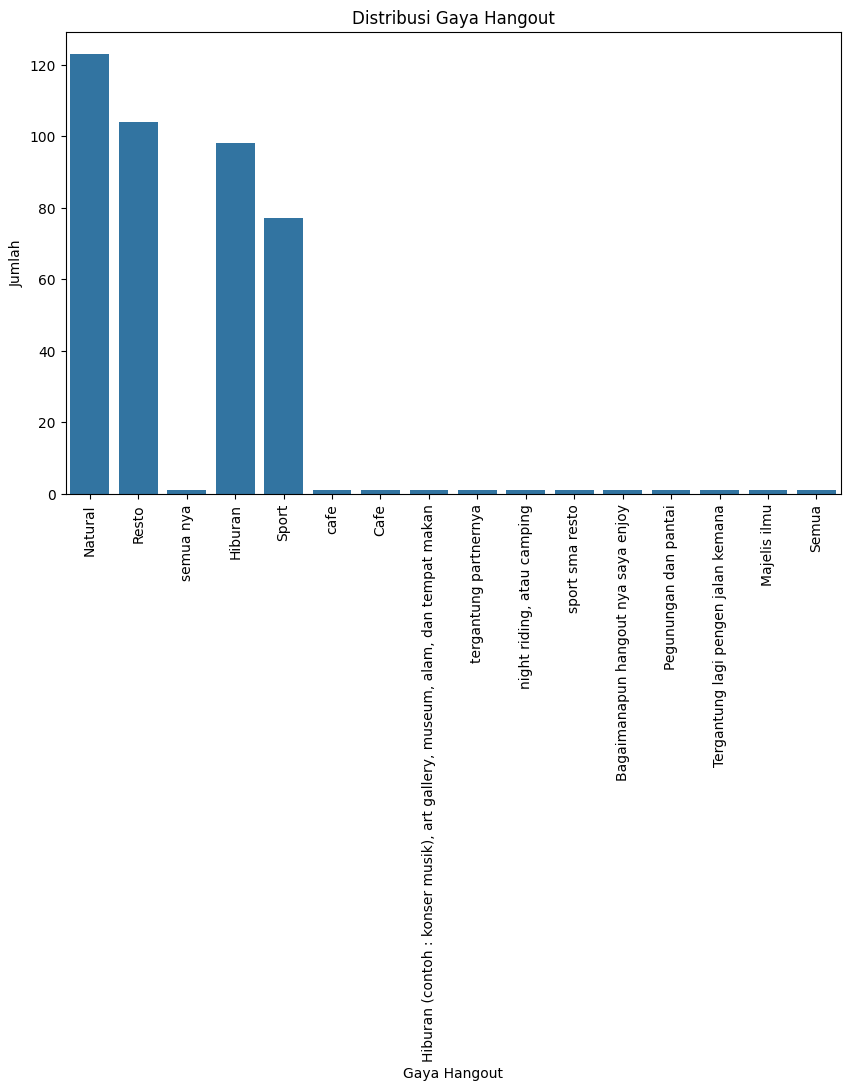

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="Kamu suka Hangout yang seperti apa?")
plt.xlabel("Gaya Hangout")
plt.ylabel("Jumlah")
plt.title("Distribusi Gaya Hangout")
plt.xticks(rotation=90)
plt.show()

In [ ]:
columns_to_drop = ["Cap waktu", " Nama Lengkap ", " No Telepon"]
data_cleaned = data.drop(columns=columns_to_drop)

In [ ]:
label_encoders = {}
for column in data_cleaned.columns:
    if data_cleaned[column].dtype == 'object':
        le = LabelEncoder()
        data_cleaned[column] = le.fit_transform(data_cleaned[column].astype(str))
        label_encoders[column] = le

In [ ]:
target = "Kamu suka Hangout yang seperti apa?"
X = data_cleaned.drop(columns=[target])
y = data_cleaned[target]


In [ ]:
df = pd.concat([X, y], axis=1)
class_counts = df[target].value_counts()
minority_classes = class_counts[class_counts < 6].index

In [ ]:
for minority_class in minority_classes:
    minority_samples = df[df[target] == minority_class]
    df = pd.concat([df, resample(minority_samples, replace=True, n_samples=6, random_state=42)])

X = df.drop(columns=[target])
y = df[target]

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest with SMOTE + Class Weight Accuracy:", rf_accuracy)
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest with SMOTE + Class Weight Accuracy: 0.8654822335025381
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        28
           2       0.22      0.21      0.22        19
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        23
           5       0.45      0.35      0.39        26
           6       1.00      1.00      1.00        29
           7       0.45      0.56      0.50        25
           8       1.00      1.00      1.00        19
           9       0.70      0.66      0.68        29
          10       1.00      1.00      1.00        23
          11       0.96      1.00      0.98        26
          12       0.96      1.00      0.98        24
          13       1.00      1.00      1.00        28
          14       1.00      1.00      1.00        28
          15       0.96      1.00      0.9

In [ ]:
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest with SMOTE + Class Weight Accuracy:", rf_accuracy)
print("Random Forest Cross Validation Scores:", rf_cv_scores)
print("Random Forest Cross Validation Mean:", rf_cv_scores.mean())
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest with SMOTE + Class Weight Accuracy: 0.8654822335025381
Random Forest Cross Validation Scores: [0.87936508 0.88571429 0.86666667 0.88571429 0.88535032]
Random Forest Cross Validation Mean: 0.8805621271863309
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        28
           2       0.22      0.21      0.22        19
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        23
           5       0.45      0.35      0.39        26
           6       1.00      1.00      1.00        29
           7       0.45      0.56      0.50        25
           8       1.00      1.00      1.00        19
           9       0.70      0.66      0.68        29
          10       1.00      1.00      1.00        23
          11       0.96      1.00      0.98        26
          12       0.96      1.00      0.98        2

In [ ]:
feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

<ipython-input-17-ee181a56688f>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='Feature', x='Importance', palette='Blues_r')


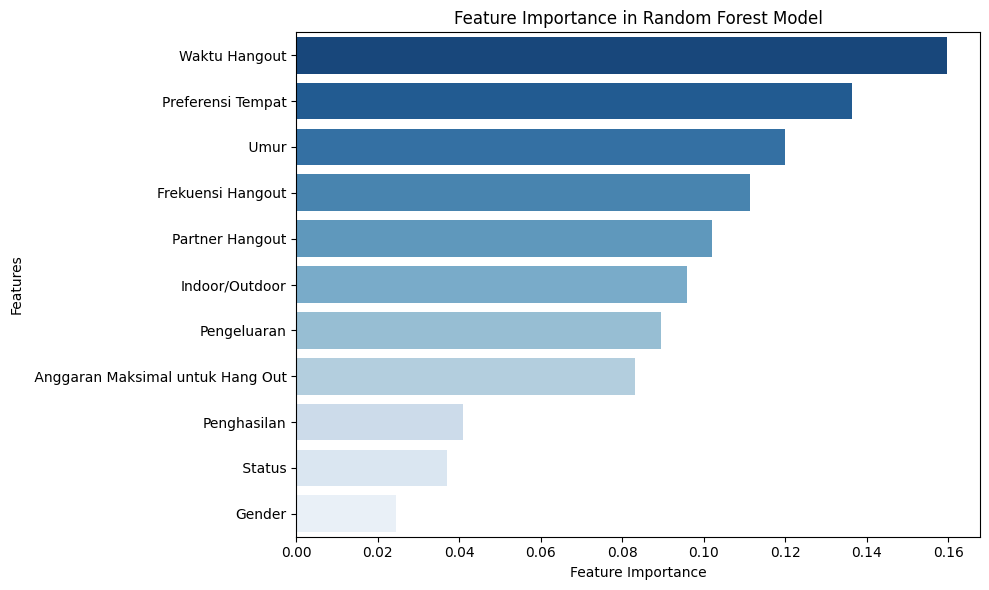

In [ ]:
feature_name_mapping = {
    "Biasanya kamu Hangout kapan?": "Waktu Hangout",
    "Apakah kamu tipikal Hang Out yang suka di tempat rame atau sepi ?": "Preferensi Tempat",
    "Umur": "Umur",
    "Seberapa sering kamu Hangout?": "Frekuensi Hangout",
    "Biasanya kamu Hangout dengan siapa?": "Partner Hangout",
    "Apakah kamu suka tempat hang out di dalam ruangan (indoor) atau di luar ruangan (outdoor) ?": "Indoor/Outdoor",
    "Pengeluaran setiap Jajan": "Pengeluaran",
    "Anggaran Maksimal untuk Hang Out": "Anggaran Maksimal",
    "Penghasilan dalam sebulan": "Penghasilan",
    "Status": "Status",
    "Gender": "Gender",
    "Kamu suka Hangout yang seperti apa?": "Hangout Preference"
}
importance_df['Feature'] = importance_df['Feature'].replace(feature_name_mapping)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='Blues_r')
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
svm_model = SVC(random_state=42, class_weight='balanced', probability=True)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM with SMOTE + Class Weight Accuracy:", svm_accuracy)
print("Classification Report:\n", classification_report(y_test, svm_predictions))

SVM with SMOTE + Class Weight Accuracy: 0.8527918781725888
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        28
           2       0.26      0.26      0.26        19
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        23
           5       0.43      0.23      0.30        26
           6       0.94      1.00      0.97        29
           7       0.60      0.48      0.53        25
           8       1.00      1.00      1.00        19
           9       0.41      0.62      0.49        29
          10       1.00      1.00      1.00        23
          11       1.00      1.00      1.00        26
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        28
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00        2

In [ ]:
svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')
print("SVM with SMOTE + Class Weight Accuracy:", svm_accuracy)
print("SVM Cross Validation Scores:", svm_cv_scores)
print("SVM Cross Validation Mean:", svm_cv_scores.mean())
print("Classification Report:\n", classification_report(y_test, svm_predictions))

SVM with SMOTE + Class Weight Accuracy: 0.8527918781725888
SVM Cross Validation Scores: [0.84761905 0.86984127 0.86031746 0.82857143 0.85031847]
SVM Cross Validation Mean: 0.8513335355373572
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        28
           2       0.26      0.26      0.26        19
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        23
           5       0.43      0.23      0.30        26
           6       0.94      1.00      0.97        29
           7       0.60      0.48      0.53        25
           8       1.00      1.00      1.00        19
           9       0.41      0.62      0.49        29
          10       1.00      1.00      1.00        23
          11       1.00      1.00      1.00        26
          12       1.00      1.00      1.00        24
          13       1.00     

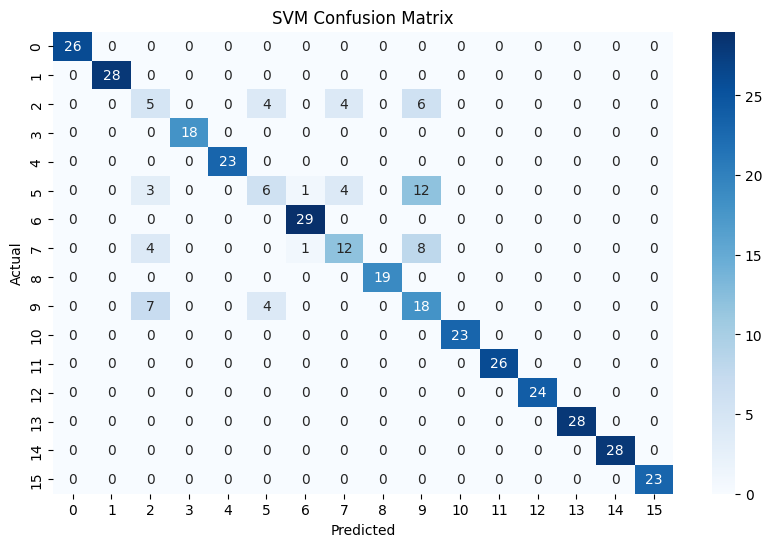

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, svm_predictions), annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy')
rf_grid_search.fit(X_train, y_train)
best_rf_model = rf_grid_search.best_estimator_
best_rf_accuracy = accuracy_score(y_test, best_rf_model.predict(X_test))
print("Optimized Random Forest Accuracy:", best_rf_accuracy)

Optimized Random Forest Accuracy: 0.868020304568528


In [ ]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
svm_grid_search = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5, scoring='accuracy')
svm_grid_search.fit(X_train, y_train)
best_svm_model = svm_grid_search.best_estimator_
best_svm_predictions = best_svm_model.predict(X_test)
best_svm_accuracy = accuracy_score(y_test, best_svm_predictions)
print("Optimized SVM Accuracy:", best_svm_accuracy)

Optimized SVM Accuracy: 0.8756345177664975


In [ ]:
print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"Optimized Random Forest Accuracy: {best_rf_accuracy}")
print(f"\nRandom Forest Classification Report:\n{classification_report(y_test, rf_predictions)}")

print("===============================================================================")

print(f"\nSVM Accuracy: {svm_accuracy}")
print(f"Optimized SVM Accuracy: {best_svm_accuracy}")
print(f"\nSVM Classification Report:\n{classification_report(y_test, svm_predictions)}")

Random Forest Accuracy: 0.8654822335025381
Optimized Random Forest Accuracy: 0.868020304568528

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        28
           2       0.22      0.21      0.22        19
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        23
           5       0.45      0.35      0.39        26
           6       1.00      1.00      1.00        29
           7       0.45      0.56      0.50        25
           8       1.00      1.00      1.00        19
           9       0.70      0.66      0.68        29
          10       1.00      1.00      1.00        23
          11       0.96      1.00      0.98        26
          12       0.96      1.00      0.98        24
          13       1.00      1.00      1.00        28
          14       1.00      1.00      1.00        28
  

<ipython-input-29-a5cd7e5fe95a>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


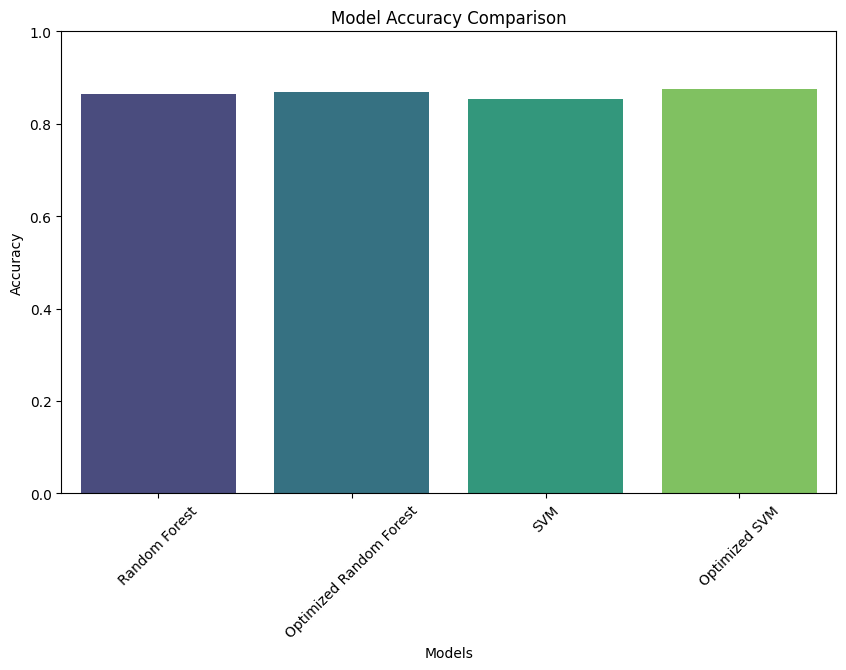

In [ ]:
models = ['Random Forest', 'Optimized Random Forest', 'SVM', 'Optimized SVM']
accuracies = [rf_accuracy, best_rf_accuracy, svm_accuracy, best_svm_accuracy]
cv_means = [rf_cv_scores.mean(), svm_cv_scores.mean(), best_svm_accuracy]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

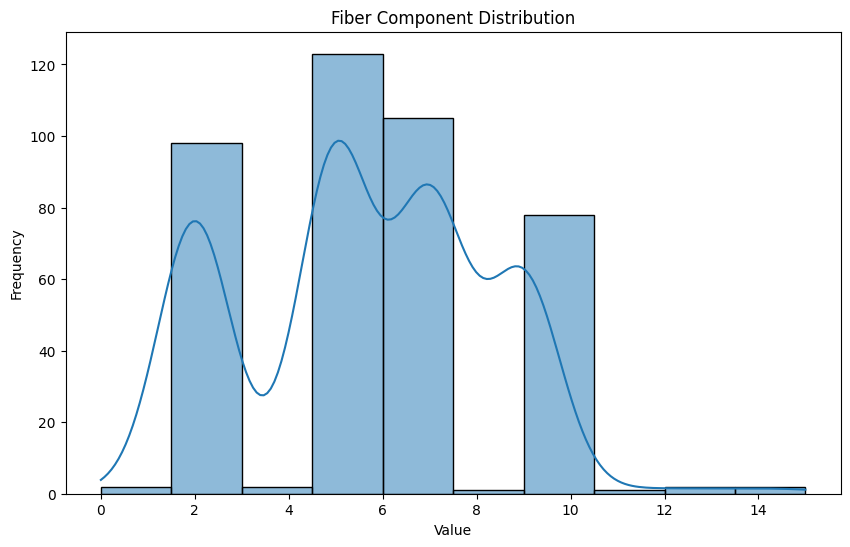

In [ ]:
fiber_component_column = "Kamu suka Hangout yang seperti apa?"
plt.figure(figsize=(10, 6))
sns.histplot(data_cleaned[fiber_component_column], kde=True, bins=10)
plt.title('Fiber Component Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# DONE!!!